# AWS Glue Studio Notebook
##### You are now running a AWS Glue Studio notebook; To start using your notebook you need to start an AWS Glue Interactive Session.


#### Optional: Run this cell to see available notebook commands ("magics").


In [ ]:
%help

####  Run this cell to set up and start your interactive session.


In [6]:
%idle_timeout 2880
%glue_version 4.0
%worker_type G.1X
%number_of_workers 2

import sys
from awsglue.transforms import *
from awsglue.utils import getResolvedOptions
from pyspark.context import SparkContext
from awsglue.context import GlueContext
from awsglue.job import Job


  
sc = SparkContext.getOrCreate()
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)

You are already connected to a glueetl session a9ce1aff-840e-44c9-a6fe-a471b1c2ece2.

No change will be made to the current session that is set as glueetl. The session configuration change will apply to newly created sessions.


Current idle_timeout is 2880 minutes.
idle_timeout has been set to 2880 minutes.


You are already connected to a glueetl session a9ce1aff-840e-44c9-a6fe-a471b1c2ece2.

No change will be made to the current session that is set as glueetl. The session configuration change will apply to newly created sessions.


Setting Glue version to: 4.0


You are already connected to a glueetl session a9ce1aff-840e-44c9-a6fe-a471b1c2ece2.

No change will be made to the current session that is set as glueetl. The session configuration change will apply to newly created sessions.


Previous worker type: G.1X
Setting new worker type to: G.1X


You are already connected to a glueetl session a9ce1aff-840e-44c9-a6fe-a471b1c2ece2.

No change will be made to the current session that is set as glueetl. The session configuration change will apply to newly created sessions.


Previous number of workers: 2
Setting new number of workers to: 2



#### Accedemos a la Tabla Cliente en la BD lds_raw

In [7]:
dyf = glueContext.create_dynamic_frame.from_catalog(database='lds_raw', table_name='cliente')
dyf.printSchema()

root
|-- id_cliente: long
|-- tipo_cliente: string
|-- dni: string
|-- celular: string
|-- email: string
|-- id_ubicacion: long
|-- fecha_alta: string
|-- estado_cliente: string


#### Creamos el Dataframe


In [8]:
df = dyf.toDF()
df.show()

+----------+------------+--------+---------+--------------------+------------+----------+--------------+
|id_cliente|tipo_cliente|     dni|  celular|               email|id_ubicacion|fecha_alta|estado_cliente|
+----------+------------+--------+---------+--------------------+------------+----------+--------------+
|         1| Residencial|70XXXX39|934XXX822|cliente00001***@c...|          40|2024-10-10|        ACTIVO|
|         2| Residencial|70XXXX19|953XXX344|cliente00002***@c...|          31|2022-07-18|        ACTIVO|
|         3| Residencial|66XXXX53|926XXX967|cliente00003***@c...|           9|2023-03-08|        ACTIVO|
|         4|   Comercial|43XXXX95|900XXX531|cliente00004***@c...|          43|2019-06-08|        ACTIVO|
|         5|   Comercial|53XXXX85|902XXX950|cliente00005***@c...|          15|2021-03-15|        ACTIVO|
|         6| Residencial|14XXXX13|950XXX255|cliente00006***@c...|          41|2021-02-24|        ACTIVO|
|         7|   Comercial|72XXXX20|925XXX814|cliente0000

### Nulos Por Columna

In [9]:
import pyspark.sql.functions as F

df.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+----------+------------+---+-------+-----+------------+----------+--------------+
|id_cliente|tipo_cliente|dni|celular|email|id_ubicacion|fecha_alta|estado_cliente|
+----------+------------+---+-------+-----+------------+----------+--------------+
|         0|           0|  0|      0|    0|           0|         0|             0|
+----------+------------+---+-------+-----+------------+----------+--------------+


### Blancos por Columna

In [10]:
df.select([
    F.count(F.when(F.col(c) == "", c)).alias(c)
    for c in df.columns if df.schema[c].dataType.simpleString() == "string"
]).show()

+------------+---+-------+-----+----------+--------------+
|tipo_cliente|dni|celular|email|fecha_alta|estado_cliente|
+------------+---+-------+-----+----------+--------------+
|           0|  0|      0|    0|         0|             0|
+------------+---+-------+-----+----------+--------------+


### Segmentación por Tipo de Cliente

In [11]:
df.groupBy("tipo_cliente").count().orderBy("count", ascending=False).show()

+-----------------+-----+
|     tipo_cliente|count|
+-----------------+-----+
|      Residencial| 8500|
|        Comercial| 1000|
|       Industrial|  200|
|Alumbrado Público|  150|
|         Gobierno|  150|
+-----------------+-----+


<BarContainer object of 5 artists>



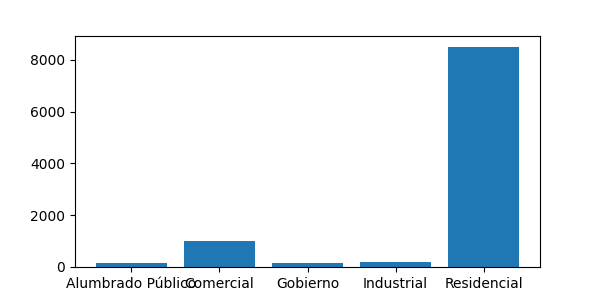

In [22]:
import matplotlib.pyplot as plt

X = df.groupBy("tipo_cliente").count().orderBy("tipo_cliente")
Y = X.toPandas()


plt.bar(Y["tipo_cliente"],Y["count"])


%matplot plt


### Segmentación por Estado de Cliente

In [21]:
df.groupBy("estado_cliente").count().show()

+--------------+-----+
|estado_cliente|count|
+--------------+-----+
|    SUSPENDIDO|   92|
|        ACTIVO| 9698|
|      INACTIVO|  210|
+--------------+-----+
